# Customer Churn Predection

**Problem Statement:** Predict whether a customer will churn or not.

**Dataset:** Telecom Customer Churn Dataset ( Keggle link : https://www.kaggle.com/datasets/blastchar/telco-customer-churn )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score,f1_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6587,7426-GSWPO,Male,1,No,No,64,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.50,6548.65,No
387,1708-PBBOA,Female,0,No,No,42,No,No phone service,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Electronic check,54.75,2348.45,No
7003,4501-VCPFK,Male,0,No,No,26,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,1022.5,No
4177,3470-BTGQO,Male,0,No,Yes,21,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,45.65,985.05,No
3049,0268-QKIWO,Female,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.75,58.85,Yes


## 3. EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There are NO Null values

In [ ]:
df.Churn.value_counts(normalize=True).round(3)

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

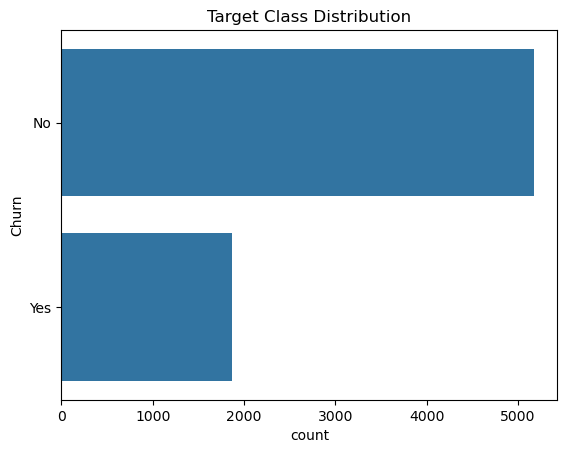

In [ ]:
sns.countplot(df.Churn)
plt.title("Target Class Distribution")
plt.show()

Dataset is Imbalanced. We will balance it later.

## 4. Data Cleaning and Preprocessing

In [ ]:
X = df.drop(df[['Churn']],axis=1)
y = df['Churn']

In [ ]:
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [ ]:
#Feature Selection and Extraction
X = X.drop(['customerID','Dependents','Partner','OnlineSecurity','OnlineBackup','StreamingMovies','TotalCharges','DeviceProtection'],axis=1)
X.head()

,gender,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,Female,0,1,No,No phone service,DSL,No,No,Month-to-month,Yes,Electronic check,29.85
1,Male,0,34,Yes,No,DSL,No,No,One year,No,Mailed check,56.95
2,Male,0,2,Yes,No,DSL,No,No,Month-to-month,Yes,Mailed check,53.85
3,Male,0,45,No,No phone service,DSL,Yes,No,One year,No,Bank transfer (automatic),42.30
4,Female,0,2,Yes,No,Fiber optic,No,No,Month-to-month,Yes,Electronic check,70.70


In [ ]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [ ]:
# Encoding Target Column
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
y

array([0, 0, 1, ..., 0, 1, 0], shape=(7043,))

In [ ]:
# Scaling and Encoding
encoding_cols = X.select_dtypes(exclude=['int64','float64']).columns
scaling_cols = ['tenure','MonthlyCharges']
encoding_cols,scaling_cols

(Index(['gender', 'PhoneService', 'MultipleLines', 'InternetService',
        'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling',
        'PaymentMethod'],
       dtype='object'),
 ['tenure', 'MonthlyCharges'])

In [ ]:
ohe = OneHotEncoder(drop='first')
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('OneHotEncoder',ohe,encoding_cols),
    ('StandardScaler',scaler,scaling_cols)
],remainder='passthrough')

In [ ]:
X = preprocessor.fit_transform(X)

In [ ]:
X = pd.DataFrame(X,columns=preprocessor.get_feature_names_out())
y = pd.DataFrame(y,columns=['Churn'])

In [ ]:
X.shape,y.shape

((7043, 19), (7043, 1))

In [ ]:
y.value_counts(normalize=True)

Churn
0        0.73463
1        0.26537
Name: proportion, dtype: float64

In [ ]:
# Balancing the dataset
upsample = SMOTE()
X,y = upsample.fit_resample(X,y)

In [ ]:
X.shape,y.shape

((10348, 19), (10348, 1))

In [ ]:
y.value_counts(normalize=True)

Churn
0        0.5
1        0.5
Name: proportion, dtype: float64

In [ ]:
y = y.Churn

In [ ]:
# Splitting data for training and testing
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=2)
xtrain.shape,ytest.shape

((7243, 19), (3105,))

Data is now ready to be fit on the models

## 5. Training Classification Models

In [ ]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [ ]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [ ]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 6. Comparing the Models based on Performance Metrices

In [ ]:
result = pd.DataFrame(res).sort_values(by='F1 Score Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,XGBClassifier,0.840580,0.918818,0.857607,0.931518,0.826959,0.909018,0.840737,0.918767,0.842004,0.920130
1,RandomForestClassifier,0.834138,0.998067,0.850455,0.998625,0.821092,0.997527,0.834289,0.998065,0.835516,0.998076
2,KNeighborsClassifier,0.782609,0.858070,0.868010,0.922992,0.738794,0.817739,0.783399,0.857809,0.798206,0.867183
3,SVC,0.790660,0.794836,0.834850,0.829208,0.764286,0.777062,0.791069,0.794698,0.798011,0.802288
4,LogisticRegression,0.779710,0.773436,0.830949,0.809681,0.750881,0.756229,0.780184,0.773291,0.788889,0.782043
5,DecisionTreeClassifier,0.774235,0.998067,0.783485,0.996425,0.766052,0.999724,0.774321,0.998074,0.774671,0.998072


- Slightly overfitted so we need to tune the model.

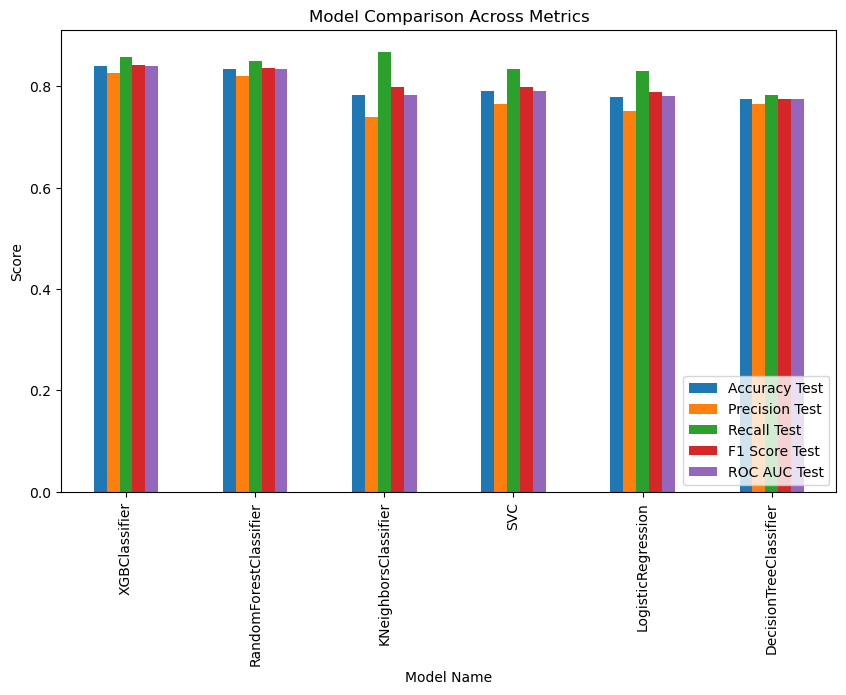

In [ ]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 7. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **XGBoost** model typically achieves the highest F1-score among all the models.

In [ ]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : XGBClassifier


## 8. Hyper-parameter Tuning of best model

In [ ]:
param = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
tuner = GridSearchCV(best_model,param_grid=param)

In [ ]:
tuner.fit(xtrain,ytrain)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'subsample': [0.8, 1.0]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [ ]:
tuner.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 7,
 'subsample': 0.8}

In [ ]:
xgb = XGBClassifier(colsample_bytree = 0.8, learning_rate=0.1, max_depth=5, subsample = 0.8)

In [ ]:
xgb.fit(xtrain,ytrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


Checking the performance after tuning

In [ ]:
ybest_test_pred = xgb.predict(xtest)
ybest_train_pred = xgb.predict(xtrain)
print(f"Test : {recall_score(ytest,ybest_test_pred)}")
print(f"Train : {recall_score(ytrain,ybest_train_pred)}")

Test : 0.8758127438231469
Train : 0.8946644664466447


- Now it is not overfitted.

In [ ]:
print(classification_report(ytest,ybest_test_pred, target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       0.87      0.79      0.83      1567
         Yes       0.80      0.88      0.84      1538

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105



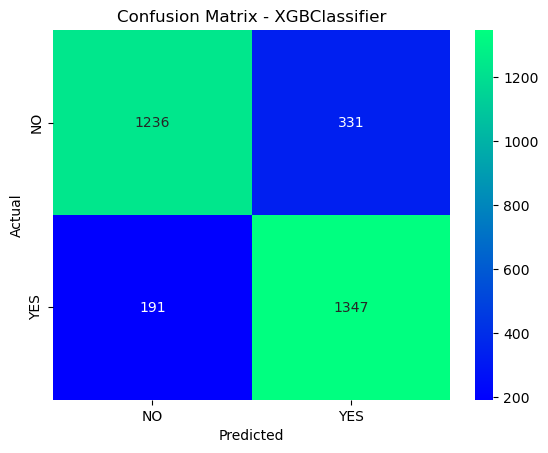

In [ ]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['NO','YES'],xticklabels=['NO','YES'])
plt.title('Confusion Matrix - XGBClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Important Features
pd.DataFrame({'Features':xtrain.columns,
              'Importance':xgb.feature_importances_
              })

,Features,Importance
0,OneHotEncoder__gender_Male,0.017164
1,OneHotEncoder__PhoneService_Yes,0.015702
2,OneHotEncoder__MultipleLines_No phone service,0.014682
3,OneHotEncoder__MultipleLines_Yes,0.020601
4,OneHotEncoder__InternetService_Fiber optic,0.082259
5,OneHotEncoder__InternetService_No,0.099036
6,OneHotEncoder__TechSupport_No internet service,0.047423
7,OneHotEncoder__TechSupport_Yes,0.032913
8,OneHotEncoder__StreamingTV_No internet service,0.044953
9,OneHotEncoder__StreamingTV_Yes,0.028377


## 9. TESTING ON UNSEEN DATA

In [ ]:
unseendata = X.sample(5)
predections = xgb.predict(unseendata)
probs = xgb.predict_proba(unseendata)[:,1] # Probablity of Predecting `Pass`
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 1, 'Yes', 'No')
results_unseen['Probablity (Churn)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (Churn)']]

,Predicted_Class,Probablity (Churn)
8012,Yes,0.955
4632,Yes,0.559
5078,No,0.098
2648,No,0.322
2250,No,0.040


## 10. Conclusion

- Trained and compared 6 classification Models.
- Used Hyper parameter tuning on the best performing model.
- Gained imformation about Important Features.
- The selected model was used to predict on Unseen data.